In [20]:
import pandas as pd
import numpy as np 

In [2]:
file_path = "../data/raw/qm9_dataset/qm9_355.xyz"

In [3]:
with open(file_path, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]
    
    n_atoms = int(lines[0])
    props = lines[1].split()

    molecule_id = props[1]
    norm_dipole_moment = float(props[4])
    norm_static_polarizability = float(props[5])
    homo = float(props[7])
    lumo = float(props[8])
    gap = float(props[9])
    smiles_line_index = 2 + n_atoms + 1
    smiles = lines[smiles_line_index].split()[0]
    
print(smiles)
print(n_atoms,molecule_id, norm_dipole_moment, norm_static_polarizability, homo, lumo, gap)

CNC(=O)C=O
11 355 1.83112 5.2806 -0.2505 -0.0726 0.178


dataset ridotto per prove  che chiamiami df_small

In [4]:

import pandas as pd

file_path = "../data/processed/qm9_gap_dataset.csv"



df = pd.read_csv(file_path)

df_small = df.head(100)

print(df_small.shape[0])
print(df_small.info())
print(df_small.head())

100
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   molecule_id                 100 non-null    int64  
 1   smiles                      100 non-null    str    
 2   norm_dipole_moment          100 non-null    float64
 3   norm_static_polarizability  100 non-null    float64
 4   homo                        100 non-null    float64
 5   lumo                        100 non-null    float64
 6   gap                         100 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 5.6 KB
None
   molecule_id         smiles  norm_dipole_moment  norm_static_polarizability  \
0            1              C           157.70699                      0.0000   
1           10           CC#N             9.22324                      3.8266   
2          100        CC1CC1C             3.30265                      0.1023   
3   

In [23]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

In [10]:
#print column smiles
df_small["smiles"].head(10)

0                   C
1                CC#N
2             CC1CC1C
3         CN1C=NC=C1C
4       O=COC(C=O)C#N
5    CC(O)(CO)C(O)C=O
6    CCC(C)(C)C(C)C=O
7    CCC(C)(C)C(O)C=O
8    CCC(C)(C)N(C)C=O
9    CCC(C)(O)C(C)C=O
Name: smiles, dtype: str

In [ ]:
#obj creation 
#RDKit start to convert SMILES to molecules
molecules = [Chem.MolFromSmiles(smiles) for smiles in df_small["smiles"]]
df_small ['molecules'] = molecules
df_small = df_small[df_small["molecules"].notnull()].reset_index(drop=True)

In [25]:
def compute_morgan_fingerprint(mol, radius=2, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

In [26]:
#ora convertiamo in finger 
X_fp = np.array([compute_morgan_fingerprint(mol) for mol in df_small["molecules"]])
X_fp.shape

[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerator
[12:48:10] DEPRECATION WARNING: please use MorganGenerat

(100, 2048)

In [27]:
#creo Y 
Y= df_small["gap"]
print(Y.head(10))  
 

0    0.5048
1    0.3640
2    0.3573
3    0.2483
4    0.2182
5    0.2305
6    0.2237
7    0.2304
8    0.2681
9    0.2266
Name: gap, dtype: float64


In [29]:
#lancio modello 
#import scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#split data
X_train, X_test, y_train, y_test = train_test_split(X_fp, Y, test_size=0.2, random_state=42)
#train model
#obj model creation
rf =RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
#predict
y_pred = rf.predict(X_test)
#evaluate
mse = mean_squared_error(y_test, y_pred)
r2_score =r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2_score}")

Mean Squared Error: 0.001572505556700001
R-squared Score: 0.5589376786611631


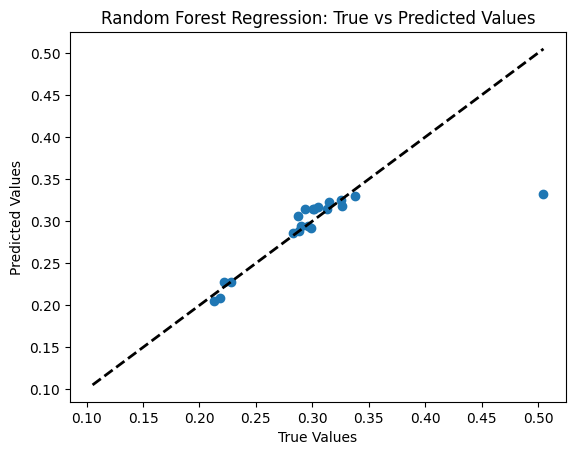

In [30]:
import matplotlib.pyplot as plt 
plt.scatter(y_test,y_pred)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression: True vs Predicted Values")
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'k--', lw=2)
plt.show()
